In [1]:
# ============================================================
# Project 2: Linear Regression — Predicting Sales from Ad Spend
# Google Colab | Scikit-learn | Python
# ============================================================

# ── Cell 1: Install & Import Libraries ──────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ── Cell 2: Create the Dataset ──────────────────────────────
# Simulated advertising spend (in $thousands) vs sales (in $thousands)
np.random.seed(42)

advertising_spend = np.linspace(5, 100, 100)          # $5K – $100K spend
noise             = np.random.normal(0, 5, 100)        # realistic noise
sales             = 5 + 0.8 * advertising_spend + noise  # true relationship

df = pd.DataFrame({
    "Advertising_Spend_K": advertising_spend.round(2),
    "Sales_K"            : sales.round(2)
})

print("📊 Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

📊 Dataset shape: (100, 2)

First 5 rows:
   Advertising_Spend_K  Sales_K
0                 5.00    11.48
1                 5.96     9.08
2                 6.92    13.77
3                 7.88    18.92
4                 8.84    10.90



📈 Basic Statistics:
       Advertising_Spend_K     Sales_K
count           100.000000  100.000000
mean             52.500000   46.480500
std              27.838892   22.927592
min               5.000000    9.080000
25%              28.750000   27.175000
50%              52.500000   46.900000
75%              76.250000   66.910000
max             100.000000   84.770000

🔗 Correlation between Ad Spend & Sales: 0.9802


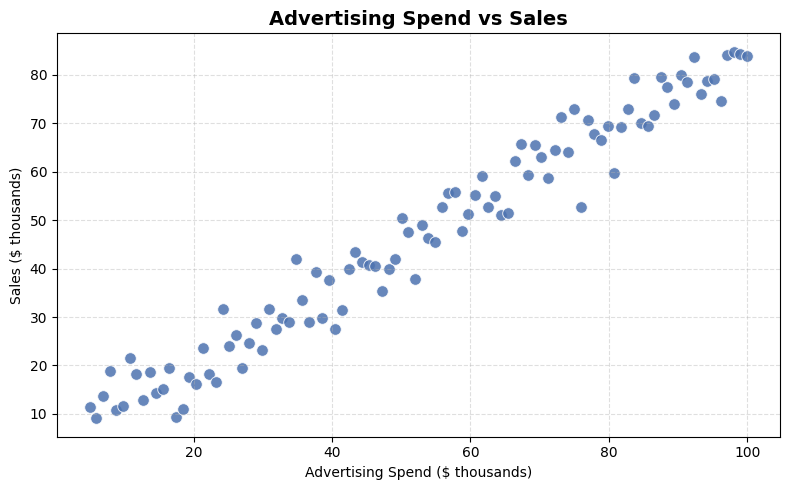

📸 Scatter plot saved.


In [3]:
# ── Cell 3: Exploratory Data Analysis (EDA) ─────────────────
print("\n📈 Basic Statistics:")
print(df.describe())

print(f"\n🔗 Correlation between Ad Spend & Sales: "
      f"{df['Advertising_Spend_K'].corr(df['Sales_K']):.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Advertising_Spend_K", y="Sales_K",
                color="#4C72B0", edgecolor="white", s=70, alpha=0.85)
plt.title("Advertising Spend vs Sales", fontsize=14, fontweight="bold")
plt.xlabel("Advertising Spend ($ thousands)")
plt.ylabel("Sales ($ thousands)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("scatter_ad_vs_sales.png", dpi=150)
plt.show()
print("📸 Scatter plot saved.")

In [4]:
# ── Cell 4: Prepare Features & Split Data ───────────────────
X = df[["Advertising_Spend_K"]]   # 2-D array (required by sklearn)
y = df["Sales_K"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"🔀 Train samples : {len(X_train)}")
print(f"🔀 Test  samples : {len(X_test)}")

🔀 Train samples : 80
🔀 Test  samples : 20


In [5]:
# ── Cell 5: Train the Linear Regression Model ───────────────
model = LinearRegression()
model.fit(X_train, y_train)

print("\n🤖 Model Trained!")
print(f"   Intercept (β₀) : {model.intercept_:.4f}")
print(f"   Coefficient (β₁): {model.coef_[0]:.4f}")
print(f"\n📐 Equation: Sales = {model.intercept_:.2f} "
      f"+ {model.coef_[0]:.2f} × Advertising_Spend")


🤖 Model Trained!
   Intercept (β₀) : 4.0647
   Coefficient (β₁): 0.8064

📐 Equation: Sales = 4.06 + 0.81 × Advertising_Spend


In [6]:
# ── Cell 6: Make Predictions ─────────────────────────────────
y_pred = model.predict(X_test)

results_df = pd.DataFrame({
    "Actual_Sales"   : y_test.values.round(2),
    "Predicted_Sales": y_pred.round(2),
    "Error"          : (y_test.values - y_pred).round(2)
})
print("\n📋 Sample Predictions (first 10 rows):")
print(results_df.head(10).to_string(index=False))


📋 Sample Predictions (first 10 rows):
 Actual_Sales  Predicted_Sales  Error
        70.13            72.33  -2.20
        52.75            49.11   3.64
        64.54            62.26   2.28
        39.95            42.92  -2.97
        35.39            42.14  -6.75
        39.92            38.27   1.65
        26.23            25.12   1.11
        69.32            70.00  -0.68
        14.36            15.84  -1.48
        11.48             8.10   3.38


In [7]:
# ── Cell 7: Evaluate the Model ──────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("\n📊 Model Performance Metrics:")
print(f"   MAE  (Mean Absolute Error)      : {mae:.4f}")
print(f"   MSE  (Mean Squared Error)       : {mse:.4f}")
print(f"   RMSE (Root Mean Squared Error)  : {rmse:.4f}")
print(f"   R²   (Coefficient of Determination): {r2:.4f}")

if r2 >= 0.9:
    print("\n✅ Excellent fit! The model explains >{:.0f}% of variance.".format(r2*100))
elif r2 >= 0.7:
    print("\n👍 Good fit!")
else:
    print("\n⚠️  Model may need improvement.")


📊 Model Performance Metrics:
   MAE  (Mean Absolute Error)      : 3.0060
   MSE  (Mean Squared Error)       : 15.5427
   RMSE (Root Mean Squared Error)  : 3.9424
   R²   (Coefficient of Determination): 0.9692

✅ Excellent fit! The model explains >97% of variance.


/tmp/ipykernel_32861/902119114.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_line = np.linspace(X.min()[0], X.max()[0], 300).reshape(-1, 1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


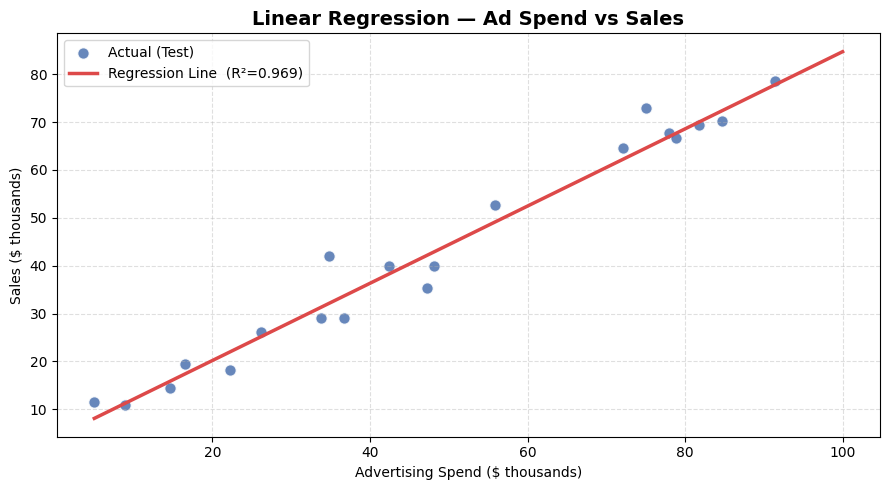

📸 Regression line plot saved.


In [8]:
# ── Cell 8: Regression Line Plot ────────────────────────────
X_line = np.linspace(X.min()[0], X.max()[0], 300).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(9, 5))
plt.scatter(X_test, y_test, color="#4C72B0", label="Actual (Test)",
            edgecolor="white", s=70, alpha=0.85)
plt.plot(X_line, y_line, color="#DD4949", linewidth=2.5,
         label=f"Regression Line  (R²={r2:.3f})")
plt.title("Linear Regression — Ad Spend vs Sales", fontsize=14, fontweight="bold")
plt.xlabel("Advertising Spend ($ thousands)")
plt.ylabel("Sales ($ thousands)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("regression_line.png", dpi=150)
plt.show()
print("📸 Regression line plot saved.")

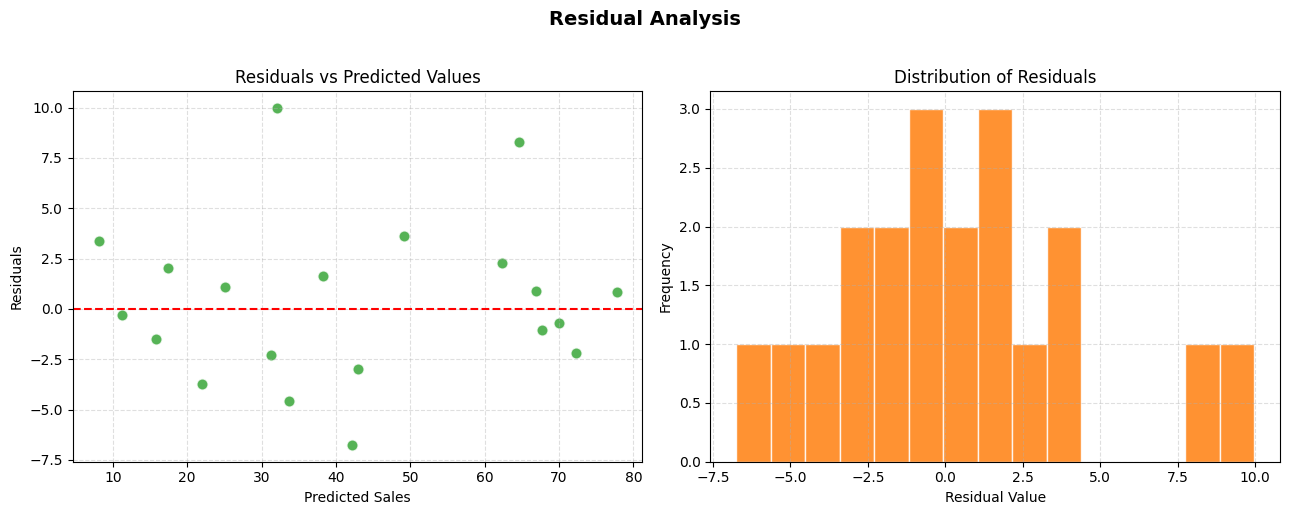

📸 Residual analysis plots saved.


In [9]:
# ── Cell 9: Residual Analysis ────────────────────────────────
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, color="#2CA02C", edgecolor="white",
                s=65, alpha=0.8)
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_title("Residuals vs Predicted Values")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residuals")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Residual Distribution
axes[1].hist(residuals, bins=15, color="#FF7F0E", edgecolor="white", alpha=0.85)
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Residual Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=150)
plt.show()
print("📸 Residual analysis plots saved.")

In [10]:
# ── Cell 10: Predict for New Custom Values ───────────────────
def predict_sales(spend_k):
    """Predict sales for a given advertising spend (in $K)."""
    spend_array = np.array([[spend_k]])
    predicted   = model.predict(spend_array)[0]
    print(f"\n💡 Ad Spend: ${spend_k}K  →  Predicted Sales: ${predicted:.2f}K")
    return predicted

# --- Try different budgets ---
predict_sales(30)
predict_sales(60)
predict_sales(85)

print("\n🎉 Project Complete! Linear Regression model built and evaluated successfully.")


💡 Ad Spend: $30K  →  Predicted Sales: $28.26K

💡 Ad Spend: $60K  →  Predicted Sales: $52.45K

💡 Ad Spend: $85K  →  Predicted Sales: $72.61K

🎉 Project Complete! Linear Regression model built and evaluated successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
